# Task 3 — Telemetry Intelligence and Modeling (Track B)
**Station:** Bhubaneswar (IGRA ID `INM00042971`)

Covers Task 3, Levels 1–3: rolling z-score anomaly detection, a pressure→altitude regression
model, and unsupervised clustering to discover the troposphere/stratosphere boundary without
being given altitude labels.

> This notebook reuses the cleaned dataset from Task 1. If `bhubaneswar_cleaned.parquet`
> (produced by Task 1 / Level 3) is present in this folder, it's loaded directly; otherwise it
> falls back to re-parsing the raw file with the same `clean_telemetry()` logic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_PATH = "INM00042971-data.txt"
PARQUET_PATH = "bhubaneswar_cleaned.parquet"

if os.path.exists(PARQUET_PATH):
    df_clean = pd.read_parquet(PARQUET_PATH)
    print(f"Loaded cleaned data from {PARQUET_PATH}: {df_clean.shape}")
else:
    # fallback: re-parse (same logic as Task 1)
    def parse_igra(filepath):
        headers, records = [], []
        current_id = -1
        with open(filepath, "r") as f:
            for line in f:
                if line.startswith("#"):
                    current_id += 1
                    headers.append(dict(
                        sounding_id=current_id, year=int(line[13:17]), month=int(line[18:20]),
                        day=int(line[21:23]), hour=int(line[24:26]),
                    ))
                else:
                    records.append(dict(
                        sounding_id=current_id, press=int(line[9:15]), gph=int(line[16:21]),
                        temp=int(line[22:27]), rh=int(line[28:33]),
                    ))
        return pd.DataFrame(headers), pd.DataFrame(records)

    df_headers, df_levels = parse_igra(DATA_PATH)
    df_levels[["press", "gph", "temp", "rh"]] = df_levels[["press", "gph", "temp", "rh"]].replace([-9999, -8888], np.nan)
    df_levels["press_hpa"] = df_levels["press"] / 100
    df_levels["temp_c"] = df_levels["temp"] / 10
    df_levels["rh_pct"] = df_levels["rh"] / 10
    df_clean = df_levels.merge(df_headers, on="sounding_id")
    print(f"Re-parsed data: {df_clean.shape}")

df_clean.head()

Loaded cleaned data from bhubaneswar_cleaned.parquet: (1560325, 12)


,sounding_id,press,gph,temp,rh,press_hpa,temp_c,rh_pct,year,month,day,hour
0,0,99300.0,NaN,262.0,937.0,993.0,26.2,93.7,1971,7,25,1
1,0,95000.0,NaN,250.0,824.0,950.0,25.0,82.4,1971,7,25,1
2,0,85000.0,1408.0,192.0,871.0,850.0,19.2,87.1,1971,7,25,1
3,0,70000.0,3057.0,110.0,961.0,700.0,11.0,96.1,1971,7,25,1
4,0,69200.0,NaN,104.0,NaN,692.0,10.4,NaN,1971,7,25,1


## Level 1 — Statistical Outlier Detection

We take one representative flight, sort it by altitude, and flag any temperature reading whose
deviation from a centered rolling mean exceeds **2 standard deviations** (Z-score approach).

In [2]:
density = (df_clean[df_clean.year >= 2023]
           .dropna(subset=["gph", "temp_c"])
           .groupby("sounding_id").size().sort_values(ascending=False))
demo_id = density.index[0]

flight = (df_clean[df_clean.sounding_id == demo_id]
          .dropna(subset=["gph", "temp_c"])
          .sort_values("gph").reset_index(drop=True))

window = 5
roll_mean = flight["temp_c"].rolling(window=window, min_periods=1, center=True).mean()
roll_std = flight["temp_c"].rolling(window=window, min_periods=1, center=True).std()
z_score = (flight["temp_c"] - roll_mean) / roll_std

flight["z_score"] = z_score
anomalies = flight[flight["z_score"].abs() > 2]
print(f"Flagged {len(anomalies)} anomalies out of {len(flight)} levels "
      f"(window={window}, threshold=|z|>2)")
anomalies[["gph", "temp_c", "z_score"]]

Flagged 0 anomalies out of 116 levels (window=5, threshold=|z|>2)


,gph,temp_c,z_score


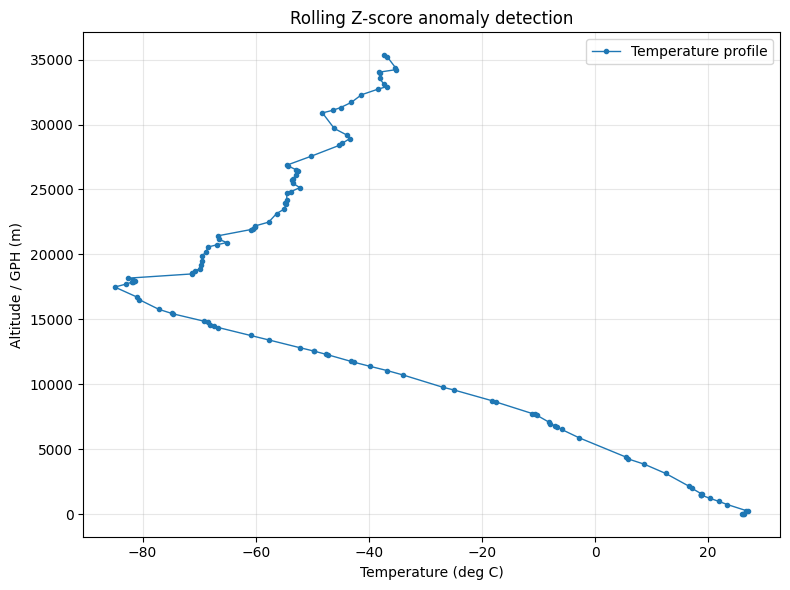

Note: 0 anomalies on a calm, well-behaved sounding is a legitimate result — try changing `demo_id` to a different sounding_id (e.g. a monsoon-season flight) to see the detector flag real spikes.


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(flight["temp_c"], flight["gph"], "-o", markersize=3, linewidth=1, label="Temperature profile")
if len(anomalies):
    ax.scatter(anomalies["temp_c"], anomalies["gph"], color="red", zorder=5, label="Flagged anomaly")
ax.set_xlabel("Temperature (deg C)")
ax.set_ylabel("Altitude / GPH (m)")
ax.set_title("Rolling Z-score anomaly detection")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("anomaly_detection.png", dpi=150)
plt.show()

print("Note: 0 anomalies on a calm, well-behaved sounding is a legitimate result — "
      "try changing `demo_id` to a different sounding_id (e.g. a monsoon-season flight) "
      "to see the detector flag real spikes.")

## Level 2 — Predictive Modeling

Physically, pressure falls off roughly *exponentially* with altitude (the barometric formula),
so we regress altitude on **log(pressure)** rather than raw pressure — this should track the true
physics much better than a plain linear fit.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

reg_data = df_clean.dropna(subset=["press_hpa", "gph"])
reg_data = reg_data[(reg_data["gph"] >= 0) & (reg_data["gph"] < 50000) & (reg_data["press_hpa"] > 0)]

X = np.log(reg_data[["press_hpa"]].values)   # log(pressure) as the single feature
y = reg_data["gph"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"R^2  : {r2:.4f}")
print(f"RMSE : {rmse:,.1f} m")
print(f"Fitted model: altitude ≈ {model.coef_[0]:.1f} * ln(pressure_hPa) + {model.intercept_:.1f}")

R^2  : 0.9946
RMSE : 523.2 m
Fitted model: altitude ≈ -6830.3 * ln(pressure_hPa) + 48004.7


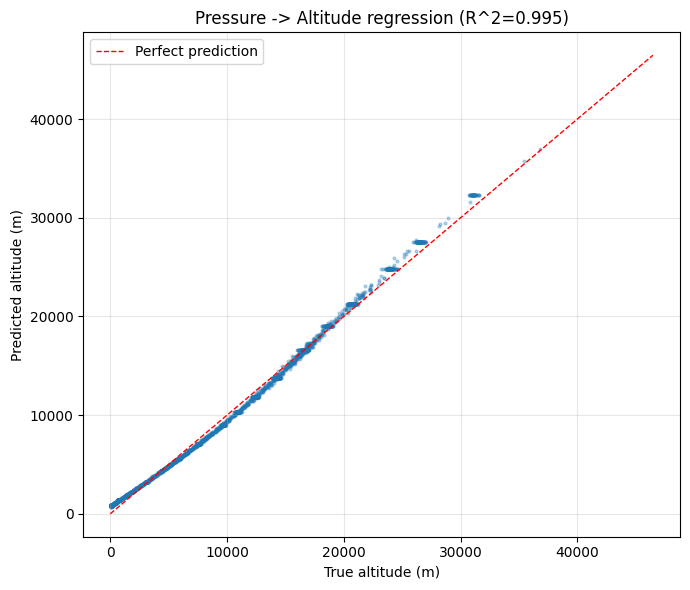

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
sample = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)
ax.scatter(y_test[sample], y_pred[sample], s=4, alpha=0.3)
lims = [0, max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("True altitude (m)")
ax.set_ylabel("Predicted altitude (m)")
ax.set_title(f"Pressure -> Altitude regression (R^2={r2:.3f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("regression_pred_vs_actual.png", dpi=150)
plt.show()

## Level 3 — Unsupervised Classification

Cluster on **temperature + pressure only** (no altitude label given to the model) and check
whether the clusters line up with the physical troposphere/stratosphere boundary — which is
where the standard *lapse rate* (temperature falling with altitude) reverses.

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

clust_data = df_clean.dropna(subset=["press_hpa", "temp_c", "gph"]).copy()
X_clust = StandardScaler().fit_transform(clust_data[["press_hpa", "temp_c"]])

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
clust_data["cluster"] = kmeans.fit_predict(X_clust)

summary = clust_data.groupby("cluster")["gph"].agg(["mean", "min", "max", "count"])
print("Altitude (gph) stats per discovered cluster (model never saw gph):")
print(summary)

Altitude (gph) stats per discovered cluster (model never saw gph):
                 mean     min      max   count
cluster                                       
0         2897.965740    -5.0   8631.0  225627
1        14488.897483  6286.0  46460.0  238146


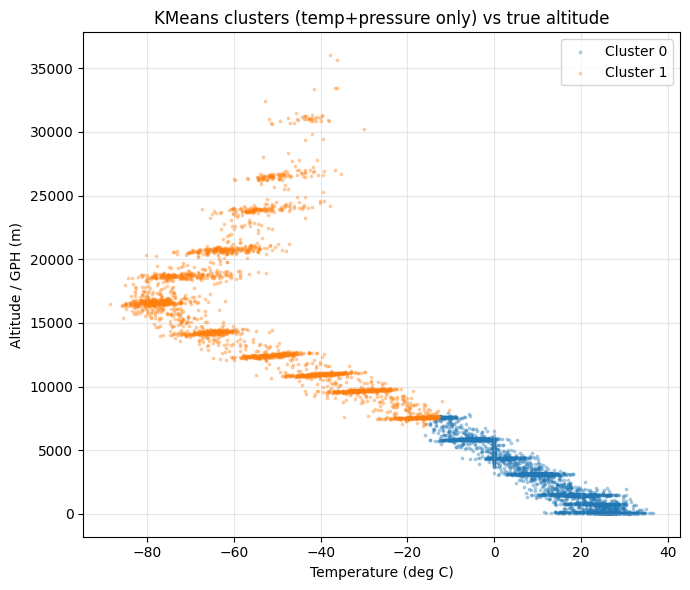

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
for c in sorted(clust_data["cluster"].unique()):
    sub = clust_data[clust_data["cluster"] == c]
    sample = sub.sample(min(3000, len(sub)), random_state=1)
    ax.scatter(sample["temp_c"], sample["gph"], s=3, alpha=0.3, label=f"Cluster {c}")
ax.set_xlabel("Temperature (deg C)")
ax.set_ylabel("Altitude / GPH (m)")
ax.set_title("KMeans clusters (temp+pressure only) vs true altitude")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()